# IMPORT DATASET

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix, accuracy_score
import scipy.stats as stats
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta

In [13]:
df = pd.read_csv('loan_data_2007_2014 (1).csv')  
pd.set_option('display.max_columns', None)        # Show all columns

df.shape
df.info()
df.describe()
df.head()


C:\Users\amsdh\AppData\Local\Temp\ipykernel_5784\2685178939.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('loan_data_2007_2014 (1).csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# IDENTIFY MISSING VALUES

In [14]:
# Assuming your DataFrame is called df
missing_values = df.isnull().sum()

# Display columns with missing values (optional: only non-zero)
print(missing_values[missing_values > 0])


emp_title                       27588
emp_length                      21008
annual_inc                          4
desc                           340304
title                              21
delinq_2yrs                        29
earliest_cr_line                   29
inq_last_6mths                     29
mths_since_last_delinq         250351
mths_since_last_record         403647
open_acc                           29
pub_rec                            29
revol_util                        340
total_acc                          29
last_pymnt_d                      376
next_pymnt_d                   227214
last_credit_pull_d                 42
collections_12_mths_ex_med        145
mths_since_last_major_derog    367311
annual_inc_joint               466285
dti_joint                      466285
verification_status_joint      466285
acc_now_delinq                     29
tot_coll_amt                    70276
tot_cur_bal                     70276
open_acc_6m                    466285
open_il_6m  

In [15]:
import io

missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 40])



desc                            72.981975
mths_since_last_delinq          53.690554
mths_since_last_record          86.566585
next_pymnt_d                    48.728567
mths_since_last_major_derog     78.773926
annual_inc_joint               100.000000
dti_joint                      100.000000
verification_status_joint      100.000000
open_acc_6m                    100.000000
open_il_6m                     100.000000
open_il_12m                    100.000000
open_il_24m                    100.000000
mths_since_rcnt_il             100.000000
total_bal_il                   100.000000
il_util                        100.000000
open_rv_12m                    100.000000
open_rv_24m                    100.000000
max_bal_bc                     100.000000
all_util                       100.000000
inq_fi                         100.000000
total_cu_tl                    100.000000
inq_last_12m                   100.000000
dtype: float64


# DROP COLUMNS

In [16]:
columns_to_drop = [
    'desc',
    'mths_since_last_delinq',
    'mths_since_last_record',
    'next_pymnt_d',
    'mths_since_last_major_derog',
    'annual_inc_joint',
    'dti_joint',
    'verification_status_joint',
    'open_acc_6m',
    'open_il_6m',
    'open_il_12m',
    'open_il_24m',
    'mths_since_rcnt_il',
    'total_bal_il',
    'il_util',
    'open_rv_12m',
    'open_rv_24m',
    'max_bal_bc',
    'all_util',
    'inq_fi',
    'total_cu_tl',
    'inq_last_12m',
    'emp_title',
    'title',
    'last_pymnt_d',
    'last_credit_pull_d',
    'id', 
    'member_id', 
    'url', 
    'zip_code',
    'pymnt_plan',
    'out_prncp_inv',
    'total_pymnt', 
    'total_pymnt_inv', 
    'total_rec_prncp', 
    'total_rec_int',
    'last_pymnt_amnt',
    'collections_12_mths_ex_med',
    'revol_bal',
    'collection_recovery_fee',
    'out_prncp', 
    'total_rec_late_fee', 
    'recoveries'
]

# Drop the columns if they exist in the DataFrame
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Optional: Print remaining columns
print("Remaining columns after drop:", df.columns.tolist())


Remaining columns after drop: ['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'initial_list_status', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']


In [17]:
df.describe()

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,policy_code,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
count,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,466256.000000,466256.000000,465945.000000,466256.000000,466285.0,466256.000000,3.960090e+05,3.960090e+05,3.960090e+05
mean,233142.000000,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,0.284678,0.804745,11.187069,0.160564,56.176947,25.064430,1.0,0.004002,1.919135e+02,1.388017e+05,3.037909e+04
std,134605.029472,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,0.797365,1.091598,4.987526,0.510863,23.732628,11.600141,0.0,0.068637,1.463021e+04,1.521147e+05,3.724713e+04
min,0.000000,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,116571.000000,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,0.000000,0.000000,8.000000,0.000000,39.200000,17.000000,1.0,0.000000,0.000000e+00,2.861800e+04,1.350000e+04
50%,233142.000000,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,0.000000,0.000000,10.000000,0.000000,57.600000,23.000000,1.0,0.000000,0.000000e+00,8.153900e+04,2.280000e+04
75%,349713.000000,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,0.000000,1.000000,14.000000,0.000000,74.700000,32.000000,1.0,0.000000,0.000000e+00,2.089530e+05,3.790000e+04
max,466284.000000,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,29.000000,33.000000,84.000000,63.000000,892.300000,156.000000,1.0,5.000000,9.152545e+06,8.000078e+06,9.999999e+06


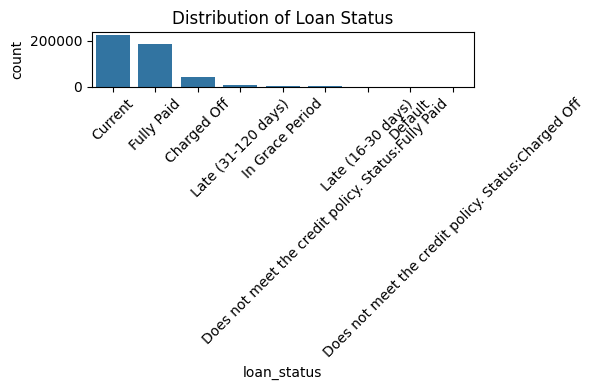

In [18]:
# Distribution of loan_status
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', order=df['loan_status'].value_counts().index)
plt.title('Distribution of Loan Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

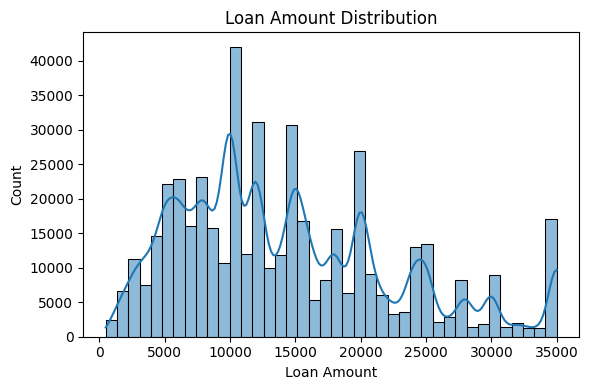

In [19]:
# Loan amount distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['loan_amnt'], bins=40, kde=True)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.tight_layout()
plt.show()

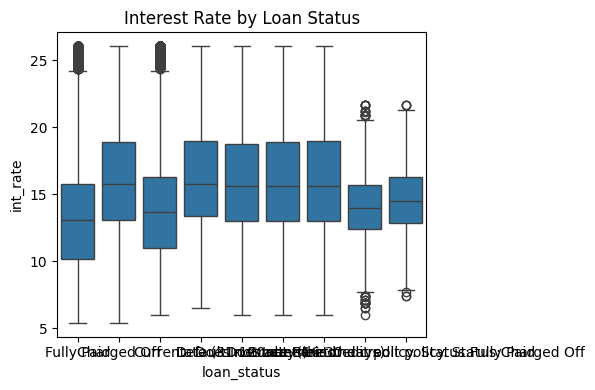

In [20]:
# Interest rate vs Loan Status
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='loan_status', y='int_rate')
plt.title('Interest Rate by Loan Status')
plt.tight_layout()
plt.show()

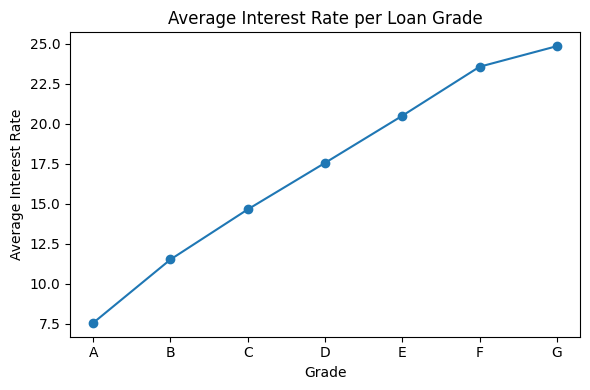

In [21]:

# Line plot: Average interest rate per loan grade
if 'grade' in df.columns and 'int_rate' in df.columns:
    grade_order = sorted(df['grade'].dropna().unique())
    grade_interest = df.groupby('grade')['int_rate'].mean().loc[grade_order]
    plt.figure(figsize=(6, 4))
    plt.plot(grade_order, grade_interest, marker='o')
    plt.title('Average Interest Rate per Loan Grade')
    plt.xlabel('Grade')
    plt.ylabel('Average Interest Rate')
    plt.tight_layout()
    plt.show()

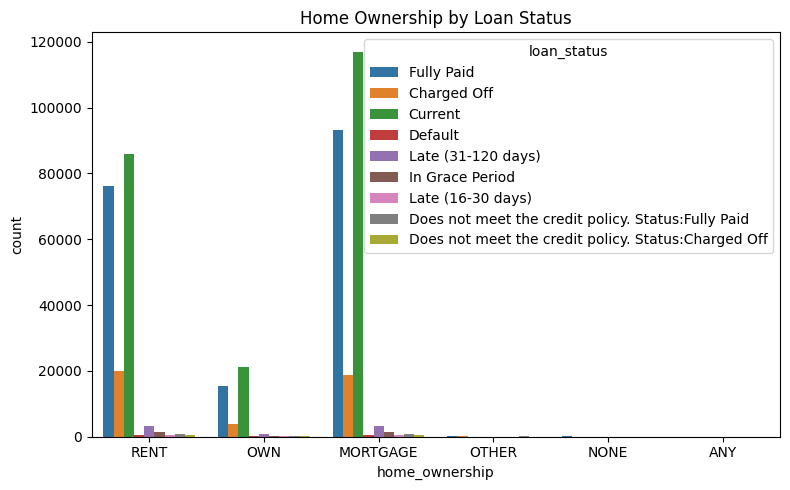

In [22]:
# Home Ownership and Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='home_ownership', hue='loan_status')
plt.title('Home Ownership by Loan Status')
plt.tight_layout()
plt.show()

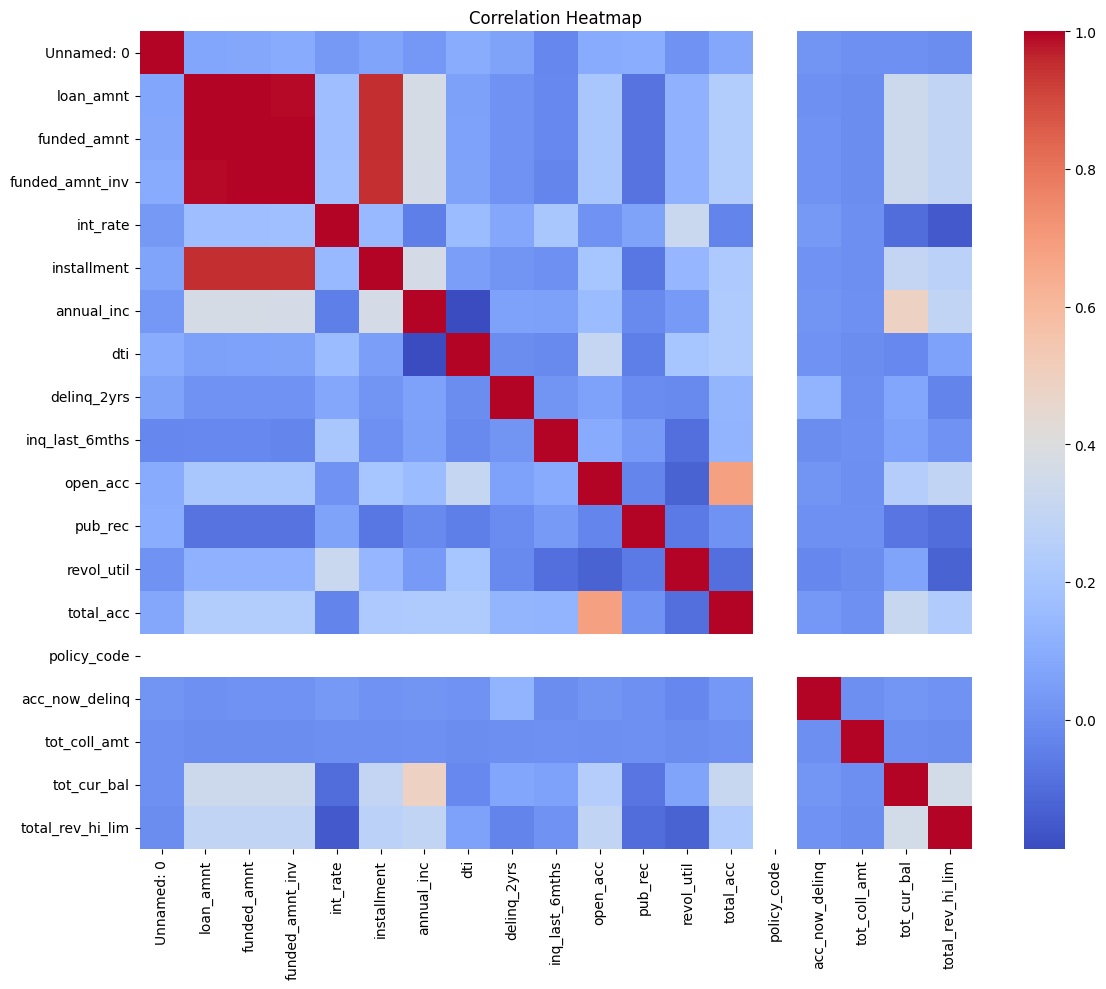

In [23]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# HANDLING MISSING VALUES

In [24]:
# Get columns with missing values and their counts
missing_counts = df.isnull().sum()

# Filter to only show columns that have missing values
missing_counts = missing_counts[missing_counts > 0]

# Sort by number of missing values (optional)
missing_counts_sorted = missing_counts.sort_values(ascending=False)

# Display the result
print("Columns with missing values and their counts:\n")
print(missing_counts_sorted)


Columns with missing values and their counts:

tot_cur_bal         70276
total_rev_hi_lim    70276
tot_coll_amt        70276
emp_length          21008
revol_util            340
total_acc              29
inq_last_6mths         29
earliest_cr_line       29
delinq_2yrs            29
open_acc               29
pub_rec                29
acc_now_delinq         29
annual_inc              4
dtype: int64


In [25]:
# Fill total_rev_hi_lim with funded_amnt
df['total_rev_hi_lim'] = df['total_rev_hi_lim'].fillna(df['funded_amnt'])

# Columns to fill with median
cols_fill_median = [
    'tot_coll_amt', 'tot_cur_bal', 'revol_util', 'delinq_2yrs',
    'inq_last_6mths', 'open_acc', 'pub_rec',
    'total_acc', 'acc_now_delinq', 'annual_inc'
]

# Fill each column with its median
for col in cols_fill_median:
    df[col] = df[col].fillna(df[col].median())


In [26]:
# Impute categorical date columns with median
date_cols = ['last_pymnt_d', 'last_credit_pull_d', 'earliest_cr_line']

for col in date_cols:
    if col in df.columns:
        # Convert to datetime
        df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')
        # Impute with median
        df[col].fillna(df[col].median())


In [27]:
def clean_emp(emp):
    if pd.isnull(emp):
        return np.nan
    emp = str(emp).strip()
    if emp == '< 1 year':
        return 0.5
    if emp == '10+ years':
        return 10
    if 'year' in emp:
        return float(emp.split()[0])
    return np.nan


In [28]:
# Clean and impute emp_length (already done partially)
df['emp_length'] = df['emp_length'].apply(clean_emp)
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())


if 'earliest_cr_line' in df.columns:
    # Correct any future years (already handled)
    df['earliest_cr_line'] = df['earliest_cr_line'].apply(
        lambda d: d - pd.DateOffset(years=100) if pd.notnull(d) and d.year > pd.Timestamp.today().year else d
    )

    # Impute missing dates with median date (after correction)
    median_date = df['earliest_cr_line'].median()
    df['earliest_cr_line'] = df['earliest_cr_line'].fillna(median_date)



In [29]:
# Get columns with missing values and their counts
missing_counts = df.isnull().sum()

# Filter to only show columns that have missing values
missing_counts = missing_counts[missing_counts > 0]
# Get columns with missing values and their counts
missing_counts = df.isnull().sum()

# Filter to only show columns that have missing values
missing_counts = missing_counts[missing_counts > 0]

# Sort by number of missing values (optional)
missing_counts_sorted = missing_counts.sort_values(ascending=False)

# Display the result
print("Columns with missing values and their counts:\n")
print(missing_counts_sorted)


Columns with missing values and their counts:

Series([], dtype: int64)


In [30]:
df

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,initial_list_status,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,0,5000,5000,4975.0,36 months,10.65,162.87,B,B2,10.0,RENT,24000.0,Verified,Dec-11,Fully Paid,credit_card,AZ,27.65,0.0,1985-01-01,1.0,3.0,0.0,83.7,9.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,5000.0
1,1,2500,2500,2500.0,60 months,15.27,59.83,C,C4,0.5,RENT,30000.0,Source Verified,Dec-11,Charged Off,car,GA,1.00,0.0,1999-04-01,5.0,3.0,0.0,9.4,4.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,2500.0
2,2,2400,2400,2400.0,36 months,15.96,84.33,C,C5,10.0,RENT,12252.0,Not Verified,Dec-11,Fully Paid,small_business,IL,8.72,0.0,2001-11-01,2.0,2.0,0.0,98.5,10.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,2400.0
3,3,10000,10000,10000.0,36 months,13.49,339.31,C,C1,10.0,RENT,49200.0,Source Verified,Dec-11,Fully Paid,other,CA,20.00,0.0,1996-02-01,1.0,10.0,0.0,21.0,37.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,10000.0
4,4,3000,3000,3000.0,60 months,12.69,67.79,B,B5,1.0,RENT,80000.0,Source Verified,Dec-11,Current,other,OR,17.94,0.0,1996-01-01,0.0,15.0,0.0,53.9,38.0,f,1,INDIVIDUAL,0.0,0.0,81539.0,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,18400,18400,18400.0,60 months,14.47,432.64,C,C2,4.0,MORTGAGE,110000.0,Source Verified,Jan-14,Current,debt_consolidation,TX,19.85,0.0,2003-04-01,2.0,18.0,0.0,77.6,36.0,w,1,INDIVIDUAL,0.0,0.0,294998.0,29900.0
466281,466281,22000,22000,22000.0,60 months,19.97,582.50,D,D5,10.0,MORTGAGE,78000.0,Verified,Jan-14,Charged Off,debt_consolidation,TN,18.45,0.0,1997-06-01,5.0,18.0,1.0,46.3,30.0,f,1,INDIVIDUAL,0.0,0.0,221830.0,39400.0
466282,466282,20700,20700,20700.0,60 months,16.99,514.34,D,D1,7.0,MORTGAGE,46000.0,Verified,Jan-14,Current,debt_consolidation,OH,25.65,0.0,2001-12-01,2.0,18.0,0.0,51.1,43.0,f,1,INDIVIDUAL,0.0,0.0,73598.0,13100.0
466283,466283,2000,2000,2000.0,36 months,7.90,62.59,A,A4,3.0,OWN,83000.0,Verified,Jan-14,Fully Paid,credit_card,CA,5.39,3.0,2003-02-01,1.0,21.0,0.0,21.5,27.0,w,1,INDIVIDUAL,0.0,0.0,591610.0,53100.0


In [31]:
print(df.head())

   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
0           0       5000         5000           4975.0   36 months     10.65   
1           1       2500         2500           2500.0   60 months     15.27   
2           2       2400         2400           2400.0   36 months     15.96   
3           3      10000        10000          10000.0   36 months     13.49   
4           4       3000         3000           3000.0   60 months     12.69   

   installment grade sub_grade  emp_length home_ownership  annual_inc  \
0       162.87     B        B2        10.0           RENT     24000.0   
1        59.83     C        C4         0.5           RENT     30000.0   
2        84.33     C        C5        10.0           RENT     12252.0   
3       339.31     C        C1        10.0           RENT     49200.0   
4        67.79     B        B5         1.0           RENT     80000.0   

  verification_status issue_d  loan_status         purpose addr_state    dti  \


In [32]:
print(df.columns)

Index(['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term',
       'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_util', 'total_acc', 'initial_list_status', 'policy_code',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim'],
      dtype='object')


# FEATURE ENGINEERING

In [33]:
distinct_loan_statuses = df['loan_status'].unique()
print(distinct_loan_statuses)


['Fully Paid' 'Charged Off' 'Current' 'Default' 'Late (31-120 days)'
 'In Grace Period' 'Late (16-30 days)'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']


In [34]:
# Re-convert to string to ensure no type errors
df['loan_status_cleaned'] = df['loan_status'].astype(str).str.strip().str.lower()

# Define set of creditworthy statuses
creditworthy_statuses = {
    "fully paid",
    "current",
    "does not meet the credit policy. status:fully paid"
}

# Apply binarization
df['loan_status'] = df['loan_status_cleaned'].apply(lambda x: 1 if x in creditworthy_statuses else 0)

# Optional: drop the helper column
df.drop(columns=['loan_status_cleaned'], inplace=True)

# Confirm unique values
print(df['loan_status'].unique())


[1 0]


In [35]:
print(df['loan_status'].value_counts())


loan_status
1    410953
0     55332
Name: count, dtype: int64


In [36]:
print(df.emp_length.unique())

[10.   0.5  1.   3.   8.   9.   4.   5.   6.   2.   7. ]


In [37]:
def clean_emp(x):
    if pd.isna(x):
        return np.nan  # Keep as missing, handle later
    x = str(x).strip().lower()
    if '< 1' in x or '<1' in x:
        return 0.5  # More accurate than 0
    if '10+' in x or '10 +' in x:
        return 10 # Distinguish from exactly 10 years
    if 'year' in x:
        try:
            return int(x.split()[0])
        except:
            return np.nan
    try:
        return int(float(x))
    except:
        return np.nan


df['emp_length'] = df['emp_length'].apply(clean_emp)


# --- Clean term ---
df['term'] = df['term'].astype(str).str.replace(' months', '', regex=False).str.strip()
df['term'] = pd.to_numeric(df['term'], errors='coerce').astype(float)

# Verify
print(df[['emp_length', 'term']].drop_duplicates())

print(df.head())

     emp_length  term
0            10  36.0
1             0  60.0
4             1  60.0
5             3  36.0
6             8  60.0
7             9  36.0
8             4  60.0
10            5  60.0
12            0  36.0
16            4  36.0
18            1  36.0
19            6  36.0
20            3  60.0
23            5  36.0
25            2  36.0
27            2  60.0
30            7  36.0
50            8  36.0
55            7  60.0
61            6  60.0
64           10  60.0
387           9  60.0
   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0           0       5000         5000           4975.0  36.0     10.65   
1           1       2500         2500           2500.0  60.0     15.27   
2           2       2400         2400           2400.0  36.0     15.96   
3           3      10000        10000          10000.0  36.0     13.49   
4           4       3000         3000           3000.0  60.0     12.69   

   installment grade sub_grade  emp_length home_o

In [38]:
print(df.emp_length.unique())

[10  0  1  3  8  9  4  5  6  2  7]


In [39]:
from dateutil.relativedelta import relativedelta

# Convert columns to datetime
for col in ['issue_d', 'earliest_cr_line']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')

# Correct future dates (like 2085 → 1985)
for col in ['issue_d', 'earliest_cr_line']:
    df[col] = df[col].apply(
        lambda d: d - pd.DateOffset(years=100) if pd.notnull(d) and d.year > pd.Timestamp.today().year else d
    )

# Calculate months between earliest_cr_line and issue_d
df['months_since_credit_line'] = (
    df['issue_d'].dt.to_period('M') - df['earliest_cr_line'].dt.to_period('M')
).apply(lambda x: x.n if x.n >= 0 else np.nan)

df['months_since_credit_line'] = df['months_since_credit_line'].astype('Int64')

print("Unique values in months_since_credit_line:", df['months_since_credit_line'].unique())


Unique values in months_since_credit_line: <IntegerArray>
[323, 152, 121, 190, 191,  85,  77,  59,  92,  87,
 ...
 842, 761, 648, 793, 649, 637, 733, 708, 686, 696]
Length: 690, dtype: Int64


In [40]:
print("\nSample of 'months_since_credit_line':")
print(df['months_since_credit_line'].describe())
print(df['months_since_credit_line'].isnull().sum(), "missing values")
print(df['months_since_credit_line'].head(10))



Sample of 'months_since_credit_line':
count      466285.0
mean     191.234865
std       87.689098
min             6.0
25%           132.0
50%           174.0
75%           235.0
max           842.0
Name: months_since_credit_line, dtype: Float64
0 missing values
0    323
1    152
2    121
3    190
4    191
5     85
6     77
7     59
8     92
9     87
Name: months_since_credit_line, dtype: Int64


In [41]:
# Check extreme outliers
extreme_outliers = df[df['months_since_credit_line'] > 600]
print(f"Rows with >600 months: {len(extreme_outliers)}")
print(extreme_outliers[['earliest_cr_line', 'issue_d', 'months_since_credit_line']].head())

Rows with >600 months: 259
      earliest_cr_line    issue_d  months_since_credit_line
6137        1954-10-01 2011-10-01                       684
13997       1959-06-01 2011-06-01                       624
14015       1956-09-01 2011-06-01                       657
14118       1946-01-01 2011-06-01                       785
15315       1950-12-01 2011-05-01                       725


In [42]:
# Handle unrealistic credit history outliers

# Option 1: Cap at reasonable maximum (50 years = 600 months)
# This preserves the data while making it realistic
MAX_CREDIT_AGE = 600
df.loc[df['months_since_credit_line'] > MAX_CREDIT_AGE, 'months_since_credit_line'] = MAX_CREDIT_AGE
df.loc[df['months_since_credit_line'] > 600, 'months_since_credit_line'] = 600

print("After capping at 600 months:")
print(df['months_since_credit_line'].describe())
print(f"Values at 600: {(df['months_since_credit_line'] == 600).sum()}")

# Alternative Option 2: Remove outliers entirely
# Uncomment if you prefer to remove these rows
# outlier_mask = df['months_since_credit_line'] > 600
# df = df[~outlier_mask]
# print(f"Removed {outlier_mask.sum()} outlier rows")

# Alternative Option 3: Set outliers to missing and handle later
# Uncomment if you prefer to treat as missing data
# df.loc[df['months_since_credit_line'] > 600, 'months_since_credit_line'] = np.nan
# print(f"Set {(df['months_since_credit_line'].isna()).sum()} values to missing")

# Verify the fix
print(f"\nNew max value: {df['months_since_credit_line'].max()}")
print(f"New range: {df['months_since_credit_line'].min()} to {df['months_since_credit_line'].max()}")




After capping at 600 months:
count      466285.0
mean     191.212499
std       87.574114
min             6.0
25%           132.0
50%           174.0
75%           235.0
max           600.0
Name: months_since_credit_line, dtype: Float64
Values at 600: 267

New max value: 600
New range: 6 to 600


In [43]:
print(df.columns.tolist())


['Unnamed: 0', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'initial_list_status', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'months_since_credit_line']


In [44]:
# --- Binning for `open_acc` ---
df['open_acc_bin'] = pd.cut(
    df['open_acc'],
    bins=[-1, 0, 3, 12, 17, 22, 25, 30, np.inf],
    labels=['0', '1-3', '4-12', '13-17', '18-22', '23-25', '26-30', '>30']
)

# --- Binning for `total_acc` ---
df['total_acc_bin'] = pd.cut(
    df['total_acc'],
    bins=[-1, 25, 50, np.inf],
    labels=['<=25', '26-50', '>50']
)

# --- Binning for `total_rev_hi_lim` ---
df['total_rev_hi_lim_bin'] = pd.cut(
    df['total_rev_hi_lim'],
    bins=[-1, 5000, 10000, 20000, 30000, 40000, 55000, 95000, np.inf],
    labels=[
        '<=5K', '5K-10K', '10K-20K', '20K-30K', '30K-40K',
        '40K-55K', '55K-95K', '>95K'
    ]
)


# --- Binning for `months_since_credit_line` ---
df['months_since_credit_line_bin'] = pd.cut(
    df['months_since_credit_line'],
    bins=[-1, 160, 250, 340, 430, 520, 610, np.inf],
    labels=[
        '<160', '160-250', '250-340', '340-430',
        '430-520', '520-610', '>610'
    ]
)


# --- Binning for `annual_inc` ---
df['annual_inc_bin'] = pd.cut(
    df['annual_inc'],
    bins=[-1, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
          100000, 120000, 140000, np.inf],
    labels=[
        '<20K',
        '20K-30K',
        '30K-40K',
        '40K-50K',
        '50K-60K',
        '60K-70K',
        '70K-80K',
        '80K-90K',
        '90K-100K',
        '100K-120K',
        '120K-140K',
        '>140K'
    ]
)

# --- Binning for `term` (make sure it's numeric already: 36 or 60) ---
df['term_bin'] = df['term'].astype(str)  # keep as string like '36', '60'

# --- Binning for `emp_length` ---
emp_map = {
    0.5: '<1 year', 1: '1 year', 2: '2 years', 3: '3 years',
    4: '4 years', 5: '5 years', 6: '6 years', 7: '7 years',
    8: '8 years', 9: '9 years', 10: '10 or more years'
}
df['emp_length_bin'] = df['emp_length'].map(emp_map)
df['emp_length_bin'] = pd.Categorical(
    df['emp_length_bin'],
    categories=list(emp_map.values()),
    ordered=True
)





In [45]:
print(df.emp_length_bin.unique())


['10 or more years', NaN, '1 year', '3 years', '8 years', ..., '4 years', '5 years', '6 years', '2 years', '7 years']
Length: 11
Categories (11, object): ['<1 year' < '1 year' < '2 years' < '3 years' ... '7 years' < '8 years' < '9 years' < '10 or more years']


In [46]:
print(df)

        Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0                0       5000         5000           4975.0  36.0     10.65   
1                1       2500         2500           2500.0  60.0     15.27   
2                2       2400         2400           2400.0  36.0     15.96   
3                3      10000        10000          10000.0  36.0     13.49   
4                4       3000         3000           3000.0  60.0     12.69   
...            ...        ...          ...              ...   ...       ...   
466280      466280      18400        18400          18400.0  60.0     14.47   
466281      466281      22000        22000          22000.0  60.0     19.97   
466282      466282      20700        20700          20700.0  60.0     16.99   
466283      466283       2000         2000           2000.0  36.0      7.90   
466284      466284      10000        10000           9975.0  36.0     19.20   

        installment grade sub_grade  emp_length hom

In [47]:
print(df.acc_now_delinq.unique())

[0. 1. 2. 3. 5. 4.]


In [48]:
df['acc_now_delinq_flag'] = (df['acc_now_delinq'] > 0).astype(int)

print(df.acc_now_delinq)


0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
466280    0.0
466281    0.0
466282    0.0
466283    0.0
466284    0.0
Name: acc_now_delinq, Length: 466285, dtype: float64


# IV and WOE

In [49]:
print(df.emp_length_bin.unique())

['10 or more years', NaN, '1 year', '3 years', '8 years', ..., '4 years', '5 years', '6 years', '2 years', '7 years']
Length: 11
Categories (11, object): ['<1 year' < '1 year' < '2 years' < '3 years' ... '7 years' < '8 years' < '9 years' < '10 or more years']


In [50]:
def calc_woe_iv(df, feature, target):
    import numpy as np
    import pandas as pd
    
    lst = []
    eps = 1e-4  # to prevent division by zero

    total_good = (df[target] == 1).sum()
    total_bad = (df[target] == 0).sum()

    # Ensure the feature is categorical or binned
    for val in sorted(df[feature].dropna().unique()):
        good = ((df[feature] == val) & (df[target] == 1)).sum()
        bad = ((df[feature] == val) & (df[target] == 0)).sum()

        dist_good = good / total_good if total_good > 0 else eps
        dist_bad = bad / total_bad if total_bad > 0 else eps

        woe = np.log((dist_good + eps) / (dist_bad + eps))
        iv = (dist_good - dist_bad) * woe

        lst.append({'Value': val, 'WoE': woe, 'IV': iv, 'Good': good, 'Bad': bad})

    iv_df = pd.DataFrame(lst)
    total_iv = iv_df['IV'].sum()

    return iv_df.sort_values('Value'), total_iv




In [51]:
print(df['delinq_2yrs'].value_counts())
print(df['pub_rec'].value_counts())
print(df['acc_now_delinq'].value_counts())


delinq_2yrs
0.0     382983
1.0      56224
2.0      16310
3.0       5684
4.0       2378
5.0       1236
6.0        629
7.0        346
8.0        177
9.0        111
10.0        65
11.0        41
12.0        38
13.0        25
14.0         8
15.0         7
18.0         6
16.0         5
17.0         3
19.0         3
22.0         2
21.0         2
24.0         1
29.0         1
Name: count, dtype: int64
pub_rec
0.0     404922
1.0      53051
2.0       5624
3.0       1611
4.0        520
5.0        276
6.0        136
7.0         62
8.0         29
9.0         16
10.0        13
11.0         8
18.0         2
12.0         2
13.0         2
54.0         1
19.0         1
49.0         1
16.0         1
15.0         1
40.0         1
14.0         1
63.0         1
21.0         1
34.0         1
17.0         1
Name: count, dtype: int64
acc_now_delinq
0.0    464553
1.0      1623
2.0        92
3.0        11
4.0         4
5.0         2
Name: count, dtype: int64


In [52]:
# Cap these variables to avoid too many sparse categories
df['delinq_2yrs_bin'] = df['delinq_2yrs'].apply(lambda x: x if x <= 5 else 6)
df['pub_rec_bin'] = df['pub_rec'].apply(lambda x: x if x <= 3 else 4)
df['acc_now_delinq_bin'] = df['acc_now_delinq'].apply(lambda x: x if x <= 1 else 2)






In [53]:
# Remove duplicate feature
selected_features = [
    "annual_inc_bin", "int_rate", "open_acc_bin", "delinq_2yrs_bin", "term_bin", "pub_rec_bin", "inq_last_6mths_bin",
    "total_acc_bin", "total_rev_hi_lim_bin", "emp_length_bin", "months_since_credit_line_bin"
]

iv_dict = {}

# Calculate IV for each feature
for feature in selected_features:
    if feature in df.columns and df[feature].isnull().sum() == 0:
        try:
            iv_df, iv = calc_woe_iv(df, feature, 'loan_status')
            iv_dict[feature] = iv
        except Exception as e:
            print(f"Error for {feature}: {e}")

# Sort IV values
iv_sorted = sorted(iv_dict.items(), key=lambda x: x[1], reverse=True)

# Print IV
print("Information Value (IV) of features:")
for k, v in iv_sorted:
    print(f"{k}: {v:.4f}")

Information Value (IV) of features:
int_rate: 0.3960
annual_inc_bin: 0.0470
term_bin: 0.0408
total_rev_hi_lim_bin: 0.0396
months_since_credit_line_bin: 0.0209
total_acc_bin: 0.0038
open_acc_bin: 0.0009
pub_rec_bin: 0.0005
delinq_2yrs_bin: 0.0004


In [54]:
# Define map_woe function
def map_woe(df, feature, target):
    iv_df, _ = calc_woe_iv(df, feature, target)
    woe_map = dict(zip(iv_df['Value'], iv_df['WoE']))
    return df[feature].map(woe_map)

# Apply WOE transformation and create new columns
for feature in selected_features:
    if feature in df.columns and df[feature].isnull().sum() == 0:
        woe_feature_name = feature + "_woe"
        df[woe_feature_name] = map_woe(df, feature, target='loan_status')


In [55]:
discrete_features = ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'initial_list_status']
woe_dict_discrete = {}
for feature in discrete_features:
    if feature in df.columns:
        woe_df, iv = calc_woe_iv(df, feature, 'loan_status')
        woe_dict_discrete[feature] = woe_df  # ✅ Store the DataFrame, not a dict
        print(f"{feature} → IV = {iv:.4f}")





grade → IV = 0.2967
home_ownership → IV = 0.0201
addr_state → IV = 0.0118
verification_status → IV = 0.0210
purpose → IV = 0.0340
initial_list_status → IV = 0.0174


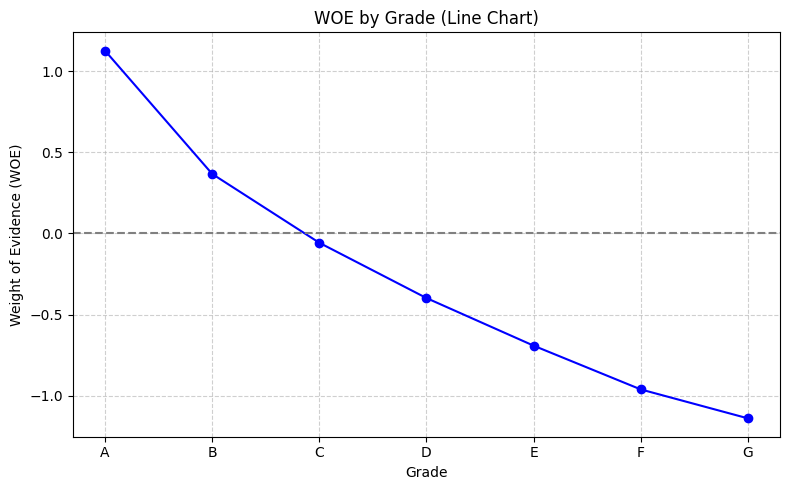

In [56]:
# Prepare and sort WOE DataFrame
woe_grade_df = woe_dict_discrete['grade'].copy()
woe_grade_df = woe_grade_df.sort_values(by='Value')  # A to G order

# Plot line chart
plt.figure(figsize=(8, 5))
plt.plot(woe_grade_df['Value'], woe_grade_df['WoE'], marker='o', linestyle='-', color='blue')

# Add labels and grid
plt.title('WOE by Grade (Line Chart)')
plt.xlabel('Grade')
plt.ylabel('Weight of Evidence (WOE)')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [57]:
# Step 1: Clean 'grade' column
df['grade'] = df['grade'].astype(str).str.strip()

# Step 2: Calculate WOE and map it
woe_df, iv = calc_woe_iv(df, 'grade', 'loan_status')
woe_map = dict(zip(woe_df['Value'], woe_df['WoE']))

# Step 3: Apply WOE mapping
df['grade_woe'] = df['grade'].map(woe_map)

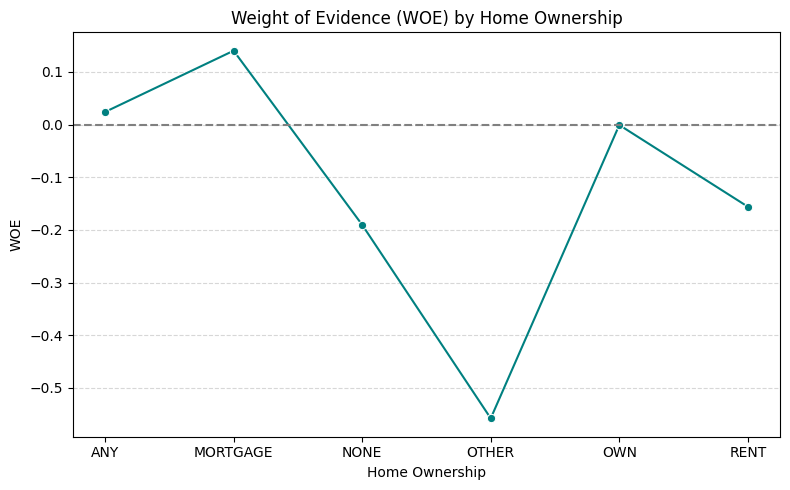

In [58]:
woe_home_df = woe_dict_discrete['home_ownership'].copy().reset_index(drop=True)

# Rename relevant columns only
woe_home_df.rename(columns={'Value': 'home_ownership', 'WoE': 'woe', 'IV': 'iv'}, inplace=True)

# Sort alphabetically
woe_home_df = woe_home_df.sort_values(by='home_ownership')

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=woe_home_df, x='home_ownership', y='woe', marker='o', color='teal')

plt.title('Weight of Evidence (WOE) by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('WOE')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [59]:
# Step 1: Clean the column
df['home_ownership'] = df['home_ownership'].astype(str).str.strip()

# Step 2: Calculate WOE and IV
woe_df, iv = calc_woe_iv(df, 'home_ownership', 'loan_status')

# Step 3: Map WOE values using the correct column name 'Value'
home_ownership_woe_map = dict(zip(woe_df['Value'], woe_df['WoE']))
df['home_ownership_woe'] = df['home_ownership'].map(home_ownership_woe_map)

# (Optional) drop original
# df.drop(columns=['home_ownership'], inplace=True)


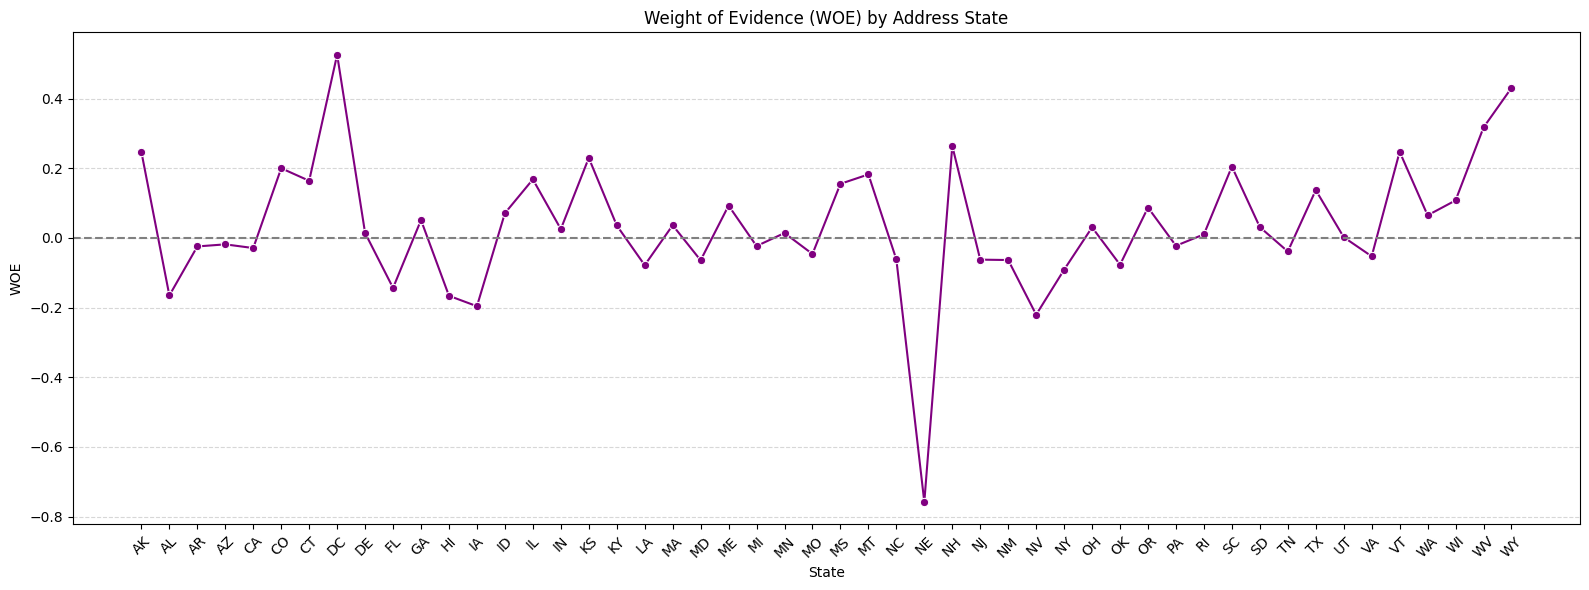

In [60]:
# Get and rename WOE DataFrame
woe_state_df = woe_dict_discrete['addr_state'].copy()
woe_state_df = woe_state_df.rename(columns={'Value': 'addr_state', 'WoE': 'woe', 'IV': 'iv'})

# Sort by state
woe_state_df = woe_state_df.sort_values(by='addr_state')

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=woe_state_df, x='addr_state', y='woe', marker='o', color='purple')
plt.title('Weight of Evidence (WOE) by Address State')
plt.xlabel('State')
plt.ylabel('WOE')
plt.axhline(0, color='gray', linestyle='--')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [61]:
df['addr_state'] = df['addr_state'].astype(str).str.strip()
woe_df, iv = calc_woe_iv(df, 'addr_state', 'loan_status')
addr_state_woe_map = dict(zip(woe_df['Value'], woe_df['WoE']))
df['addr_state_woe'] = df['addr_state'].map(addr_state_woe_map)


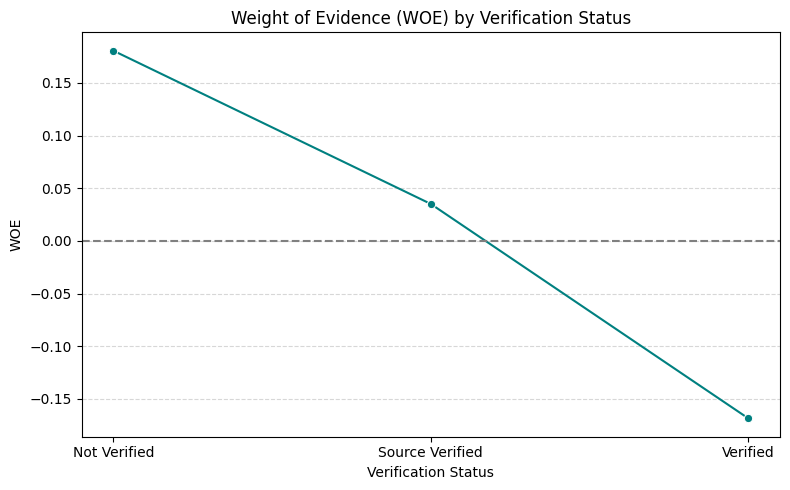

In [62]:
# Step 1: Copy and rename columns
woe_verif_df = woe_dict_discrete['verification_status'].copy().reset_index(drop=True)
woe_verif_df = woe_verif_df.rename(columns={
    'Value': 'verification_status',
    'WoE': 'woe',
    'IV': 'iv'
})

# Step 2: Sort if needed
woe_verif_df = woe_verif_df.sort_values(by='verification_status')

# Step 3: Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=woe_verif_df, x='verification_status', y='woe', marker='o', color='teal')

plt.title('Weight of Evidence (WOE) by Verification Status')
plt.xlabel('Verification Status')
plt.ylabel('WOE')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [63]:
df['verification_status'] = df['verification_status'].astype(str).str.strip()
woe_df, iv = calc_woe_iv(df, 'verification_status', 'loan_status')
ver_status_woe_map = dict(zip(woe_df['Value'], woe_df['WoE']))
df['verification_status_woe'] = df['verification_status'].map(ver_status_woe_map)


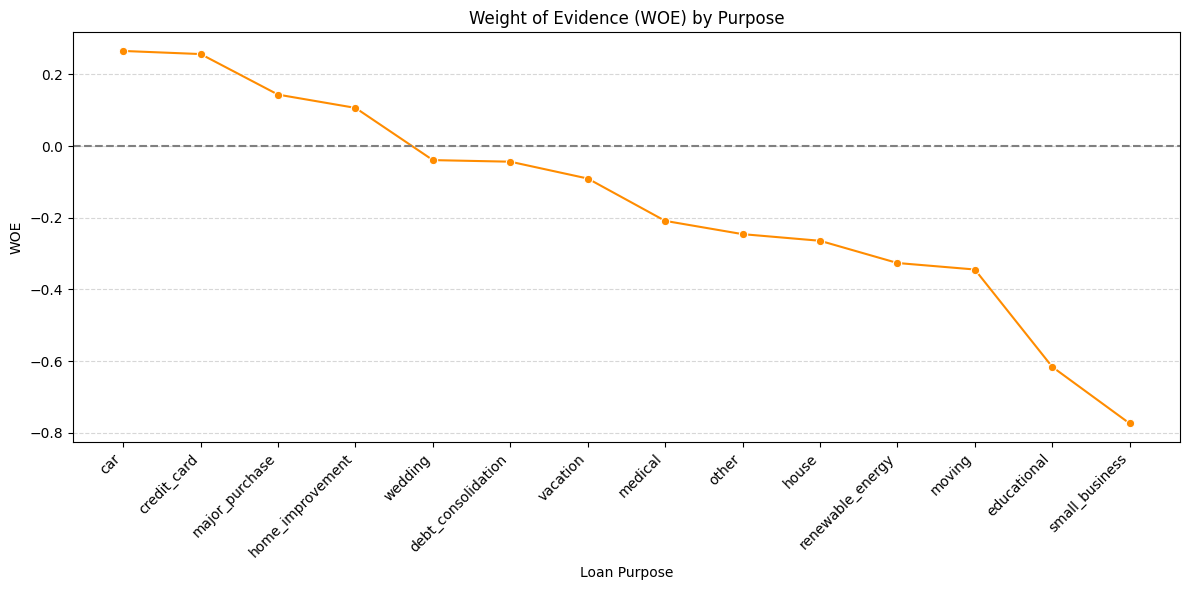

In [64]:
# Step 1: Copy and reset index
woe_purpose_df = woe_dict_discrete['purpose'].copy().reset_index(drop=True)

# Step 2: Rename only the necessary columns (safely)
woe_purpose_df = woe_purpose_df.rename(columns={
    'Value': 'purpose',
    'WoE': 'woe',
    'IV': 'iv'
})

# Step 3: Sort by WOE
woe_purpose_df = woe_purpose_df.sort_values(by='woe', ascending=False)

# Step 4: Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=woe_purpose_df, x='purpose', y='woe', marker='o', color='darkorange')

plt.title('Weight of Evidence (WOE) by Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('WOE')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [65]:
df['purpose'] = df['purpose'].astype(str).str.strip()
woe_df, iv = calc_woe_iv(df, 'purpose', 'loan_status')
purpose_woe_map = dict(zip(woe_df['Value'], woe_df['WoE']))
df['purpose_woe'] = df['purpose'].map(purpose_woe_map)


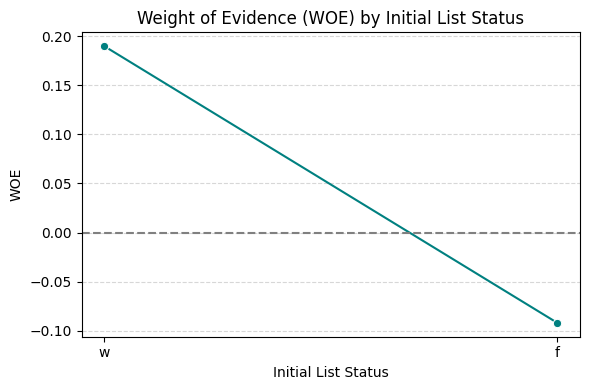

In [66]:
# Step 1: Copy and reset index
woe_status_df = woe_dict_discrete['initial_list_status'].copy().reset_index(drop=True)

# Step 2: Rename only the necessary columns safely
woe_status_df = woe_status_df.rename(columns={
    'Value': 'initial_list_status',
    'WoE': 'woe',
    'IV': 'iv'
})

# Step 3: Sort by WoE
woe_status_df = woe_status_df.sort_values(by='woe', ascending=False)

# Step 4: Plot
plt.figure(figsize=(6, 4))
sns.lineplot(data=woe_status_df, x='initial_list_status', y='woe', marker='o', color='teal')

plt.title('Weight of Evidence (WOE) by Initial List Status')
plt.xlabel('Initial List Status')
plt.ylabel('WOE')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [67]:
df['initial_list_status'] = df['initial_list_status'].astype(str).str.strip()
woe_df, iv = calc_woe_iv(df, 'initial_list_status', 'loan_status')
ils_woe_map = dict(zip(woe_df['Value'], woe_df['WoE']))
df['initial_list_status_woe'] = df['initial_list_status'].map(ils_woe_map)


In [68]:
print(df.head())

   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0           0       5000         5000           4975.0  36.0     10.65   
1           1       2500         2500           2500.0  60.0     15.27   
2           2       2400         2400           2400.0  36.0     15.96   
3           3      10000        10000          10000.0  36.0     13.49   
4           4       3000         3000           3000.0  60.0     12.69   

   installment grade sub_grade  emp_length home_ownership  annual_inc  \
0       162.87     B        B2          10           RENT     24000.0   
1        59.83     C        C4           0           RENT     30000.0   
2        84.33     C        C5          10           RENT     12252.0   
3       339.31     C        C1          10           RENT     49200.0   
4        67.79     B        B5           1           RENT     80000.0   

  verification_status    issue_d  loan_status         purpose addr_state  \
0            Verified 2011-12-01        

'annual_inc', 'open_acc', 'total_acc', 'total_rev_hi_lim',
             'loan_amnt', 'months_since_credit_line', 'earliest_cr_line']


In [69]:
print(df.term_bin.unique())

['36.0' '60.0']


In [70]:
print(df.total_acc_bin.unique())

['<=25', '26-50', '>50']
Categories (3, object): ['<=25' < '26-50' < '>50']


In [71]:
subgrade_order = [
    'A1','A2','A3','A4','A5',
    'B1','B2','B3','B4','B5',
    'C1','C2','C3','C4','C5',
    'D1','D2','D3','D4','D5',
    'E1','E2','E3','E4','E5',
    'F1','F2','F3','F4','F5',
    'G1','G2','G3','G4','G5'
]

df['sub_grade'] = pd.Categorical(
    df['sub_grade'],
    categories=subgrade_order,
    ordered=True
)

df['sub_grade_encoded'] = df['sub_grade'].cat.codes

df.drop('sub_grade', axis=1, inplace=True)


In [72]:
print(df['emp_length'].unique())


[10  0  1  3  8  9  4  5  6  2  7]


In [73]:
df['emp_length_bin'] = df['emp_length'].map({
    0.5: '<1 year',
    1: '1 year',
    2: '2 years',
    3: '3 years',
    4: '4 years',
    5: '5 years',
    6: '6 years',
    7: '7 years',
    8: '8 years',
    9: '9 years',
    10: '10 or more years'
})
df['emp_length_bin'] = df['emp_length_bin'].fillna('Unknown')



In [74]:
print(df['total_acc_bin'].describe())
print(df['annual_inc_bin'].describe())
print(df['annual_inc_bin'].value_counts().head(10))


count     466285
unique         3
top         <=25
freq      265518
Name: total_acc_bin, dtype: object
count      466285
unique         12
top       40K-50K
freq        68643
Name: annual_inc_bin, dtype: object
annual_inc_bin
40K-50K      68643
50K-60K      66514
60K-70K      54169
30K-40K      53964
70K-80K      46879
80K-90K      35039
100K-120K    33012
90K-100K     28312
20K-30K      28020
>140K        27532
Name: count, dtype: int64


In [75]:
continuous_features = ["inq_last_6mths", "open_acc", "pub_rec", "total_acc", 
                       "acc_now_delinq", "annual_inc", "emp_length", "dti"]

def bin_features(df):
    # --- Binning continuous variables ---
    df['inq_last_6mths_bin'] = pd.cut(
        df['inq_last_6mths'], 
        bins=[-1, 0, 1, 2, 3, 4, 5, np.inf],
        labels=['0 month', '1 month', '2 months', '3 months', '4 months', '5 months', '>6 months']
    )

    df['int_rate_bin'] = pd.cut(
        df['int_rate'], 
        bins=[-1, 9.61, 12.025, 15.74, 20.281, np.inf],
        labels=['Less than 9.610%', '9.610% - 12.025%', '12.025% - 15.74%', '15.74% - 20.281%', 'Greater than 20.281%']
    )

    df['pub_rec_bin'] = pd.cut(
        df['pub_rec'], 
        bins=[-1, 2, 4, np.inf],
        labels=['0-2 Records', '3-4 Records', '5+ Records']

    )

    df['acc_now_delinq_bin'] = df['acc_now_delinq'].apply(lambda x: '0' if x == 0 else '1+')


    df['dti_bin'] = pd.cut(
        df['dti'], 
        bins=[-1, 14, 35, 77, 105, 160, 203, 217, 224, 350, np.inf],
        labels=['Less than 14%', '14%-35%', '35%-77%', '77%-105%', '105%-160%',
                '161%-203%', '203%-217%', '217%-224%', '224%-350%', 'Greater than 350%']
    )
    
    return df

In [76]:

def bin_features(df):
    # Inquiries in Last 6 Months
    df['inq_last_6mths_bin'] = pd.cut(
        df['inq_last_6mths'],
        bins=[-1, 0, 1, 2, 3, 4, 5, np.inf],
        labels=["0", "1", "2", "3", "4", "5", "6"]
    )

    # Interest Rate
    df['int_rate_bin'] = pd.cut(
        df['int_rate'],
        bins=[-1, 9.61, 12.025, 15.74, 20.281, np.inf],
        labels=["<9.61%", "9.610% - 12.025%", "12.025% - 15.74%", "15.74% - 20.281%", ">20.281%"]
    )

    # Public Records
    df['pub_rec_bin'] = pd.cut(
        df['pub_rec'],
        bins=[-1, 2, 4, np.inf],
        labels=["0-2 Records", "3-4 Records", ">5 Records"]
    )

    # Total Accounts
    df['total_acc_bin'] = pd.cut(
        df['total_acc'],
        bins=[-1, 25, 50, np.inf],
        labels=["<25 Accounts", "25-50 Accounts", ">50 Accounts"]
    )

    # Open Accounts
    df['open_acc_bin'] = pd.cut(
        df['open_acc'],
        bins=[-1, 0, 3, 12, 17, 22, 25, 30, np.inf],
        labels=[
            "0 Accounts", "1-3 Accounts", "4-12 Accounts", "13-17 Accounts", 
            "18-22 Accounts", "23-25 Accounts", "26-30 Accounts", ">31 Accounts"
        ]
    )

    # Account Now Delinquent
    df['acc_now_delinq_bin'] = df['acc_now_delinq'].apply(lambda x: "0" if x == 0 else ">=1")

    # Total Revolving Credit Limit
    df['total_rev_hi_lim_bin'] = pd.cut(
        df['total_rev_hi_lim'],
        bins=[-1, 5000, 10000, 20000, 30000, 40000, 55000, 95000, np.inf],
        labels=[
            "<5000 thousands", "5000-10000 thousands", "10000-20000 thousands",
            "20000-30000 thousands", "30000-40000 thousands", "40000-55000 thousands",
            "55000-95000 thousands", ">95000 thousands"
        ]
    )

    # Annual Income
    df['annual_inc'] = pd.cut(
        df['annual_inc'],
        bins=[-1, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
              100000, 120000, 140000, np.inf],
        labels=[
            "<20000 thousands", "20000-30000 thousands", "30000-40000 thousands",
            "40000-50000 thousands", "50000-60000 thousands", "60000-70000 thousands",
            "70000-80000 thousands", "80000-90000 thousands", "90000-100000 thousands",
            "100000-120000 thousands", "120000-140000 thousands", ">140000 thousands"
        ]
    )

    # Debt-to-Income Ratio
    df['dti_bin'] = pd.cut(
        df['dti'],
        bins=[-1, 14, 35, 77, 105, 160, 203, 217, 224, 350, np.inf],
        labels=[
            "<14%", "14%-35%", "35%-77%", "77%-105%", "105%-160%",
            "161%-203%", "203%-217%", "217%-224%", "224%-350%", ">350%"
        ]
    )

    return df


In [77]:
def map_woe(df, feature, target):
    iv_df, _ = calc_woe_iv(df, feature, target)
    woe_map = dict(zip(iv_df['Value'], iv_df['WoE']))
    return df[feature].map(woe_map)


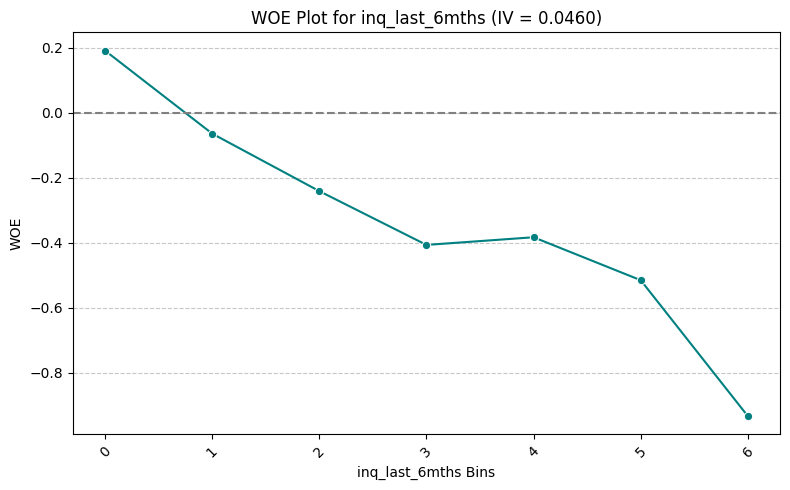

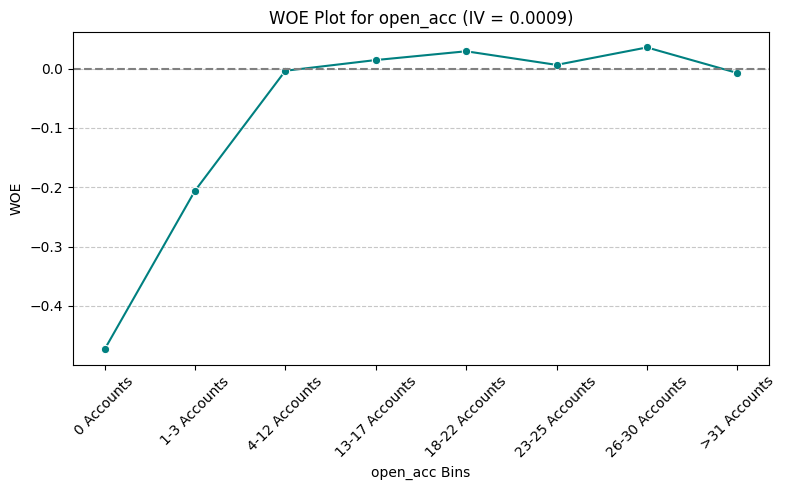

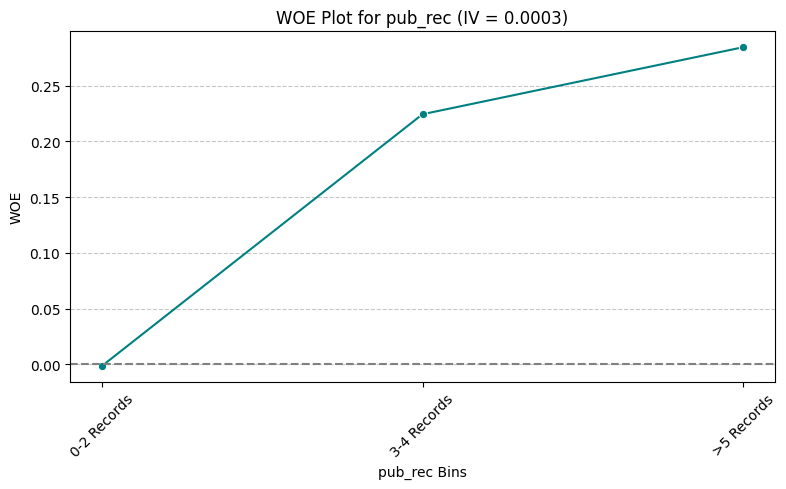

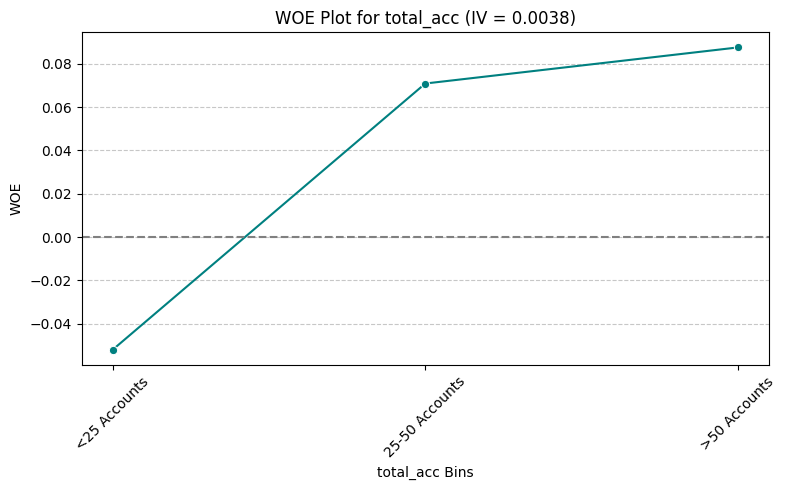

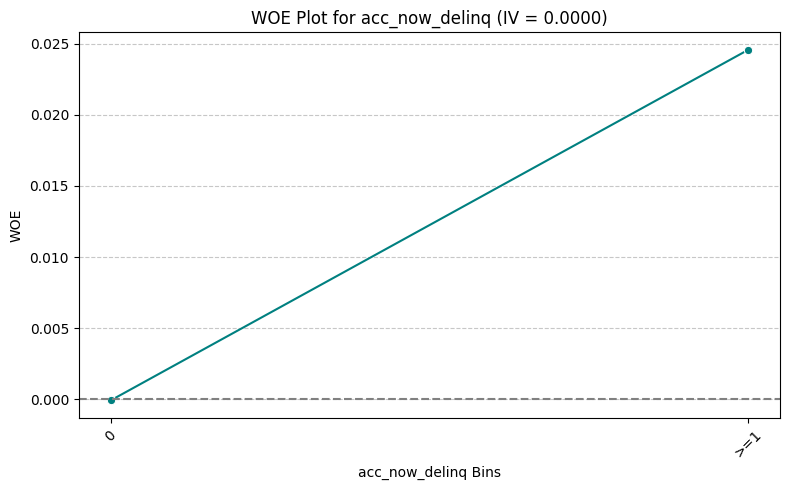

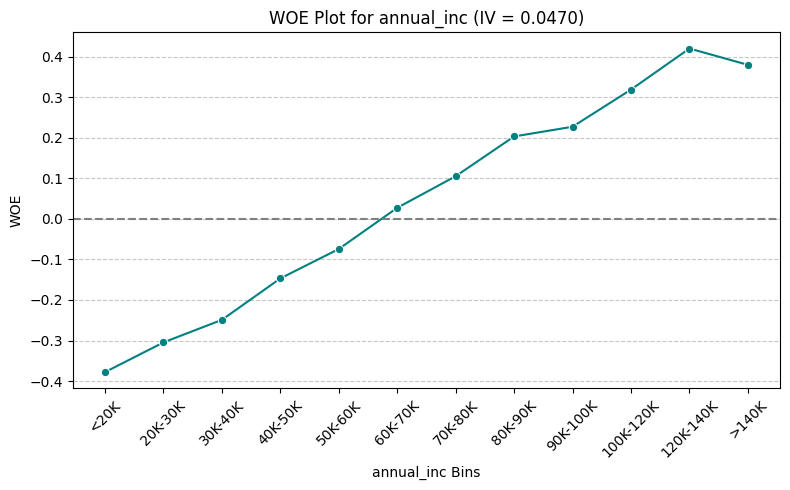

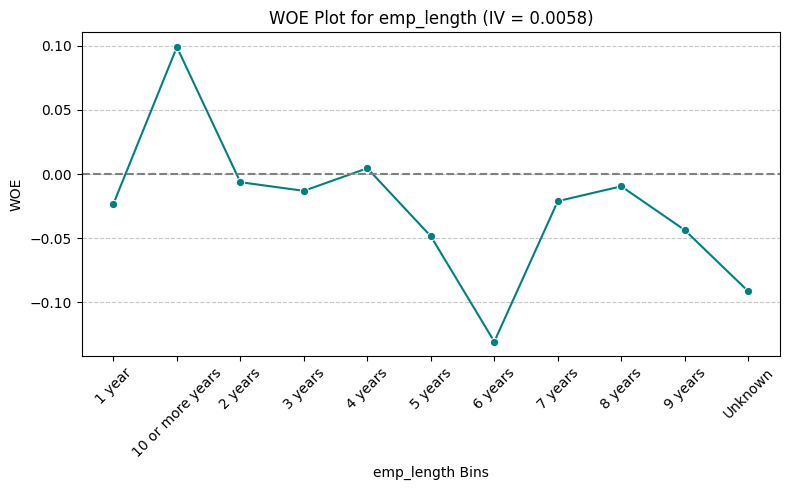

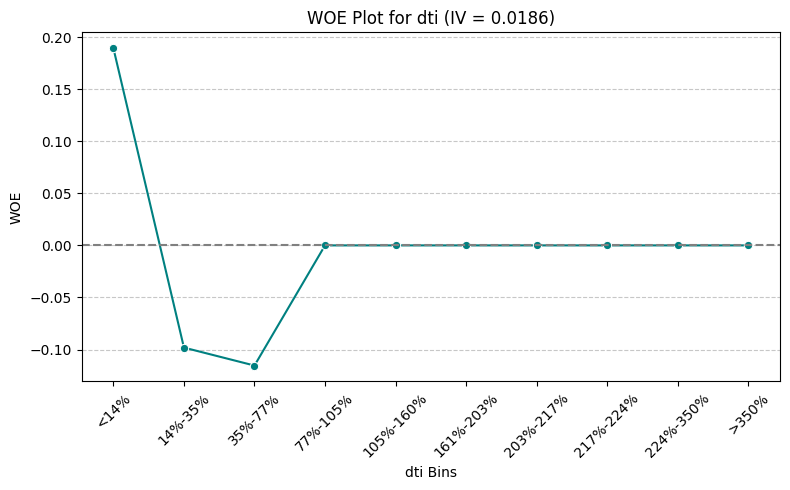

In [78]:
df = bin_features(df)  # Ensure bin columns exist

def calc_woe_iv(df, feature, target):
    df_woe = df[[feature, target]].copy()
    total_good = (df_woe[target] == 1).sum()  # Creditworthy
    total_bad = (df_woe[target] == 0).sum()   # Not creditworthy

    woe_df = (
        df_woe.groupby(feature, observed=False)
        .agg(good=(target, lambda x: (x == 1).sum()), bad=(target, lambda x: (x == 0).sum()))
        .reset_index()
    )
    woe_df['dist_good'] = woe_df['good'] / total_good
    woe_df['dist_bad'] = woe_df['bad'] / total_bad
    woe_df['WoE'] = np.log((woe_df['dist_good'] + 1e-4) / (woe_df['dist_bad'] + 1e-4))
    woe_df['IV'] = (woe_df['dist_good'] - woe_df['dist_bad']) * woe_df['WoE']
    iv = woe_df['IV'].sum()

    return woe_df[[feature, 'WoE', 'IV']], iv

# Step 6: Plot WOE graphs only for continuous features
for feature in continuous_features:
    bin_col = f"{feature}_bin"
    if bin_col not in df.columns:
        print(f"Skipping {feature}: binned column not found.")
        continue

    try:
        woe_df, iv = calc_woe_iv(df, bin_col, 'loan_status')
        woe_df.columns = ['bin', 'woe', 'iv']
        woe_df = woe_df.sort_values(by='bin')

        plt.figure(figsize=(8, 5))
        sns.lineplot(data=woe_df, x='bin', y='woe', marker='o', color='teal')
        plt.title(f'WOE Plot for {feature} (IV = {iv:.4f})')
        plt.xlabel(f'{feature} Bins')
        plt.ylabel('WOE')
        plt.axhline(0, color='gray', linestyle='--')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)  # 🔁 Tilt x-axis labels for better visibility
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error plotting WOE for {feature}: {e}")


In [79]:
final_binned_cols = {
    col.replace("_bin", ""): col for col in df.columns if col.endswith("_bin")
}
# Step 7: Define WOE mapping function
def map_woe(df, feature, target='loan_status'):
    try:
        woe_df, _ = calc_woe_iv(df, feature, target)
        woe_map = dict(zip(woe_df.iloc[:, 0], woe_df['WoE']))
        return df[feature].map(woe_map)
    except Exception as e:
        print(f"Error mapping WOE for {feature}: {e}")
        return df[feature]  # return unchanged if mapping fails
# Step 8: Create _woe columns for each binned feature
for raw_feature, bin_col in final_binned_cols.items():
    if bin_col in df.columns and df[bin_col].isnull().sum() == 0:
        woe_col = f"{raw_feature}_woe"
        df[woe_col] = map_woe(df, bin_col, target='loan_status')


In [80]:
# Drop all _bin columns if you no longer need them
# df.drop(columns=[col for col in df.columns if col.endswith('_bin')], inplace=True)


In [81]:
df['emp_length_bin'].isnull().sum()


np.int64(0)

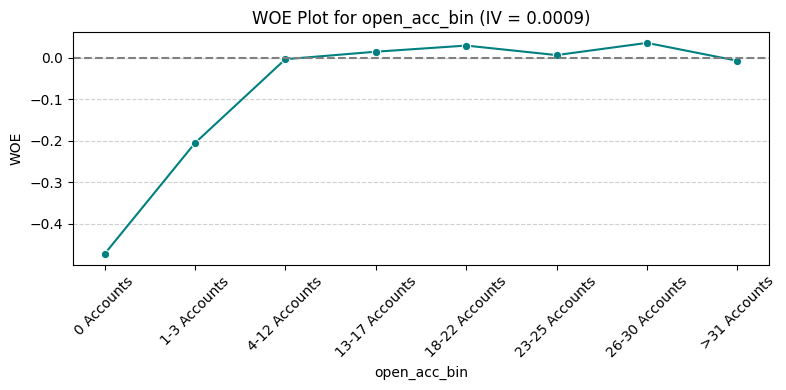

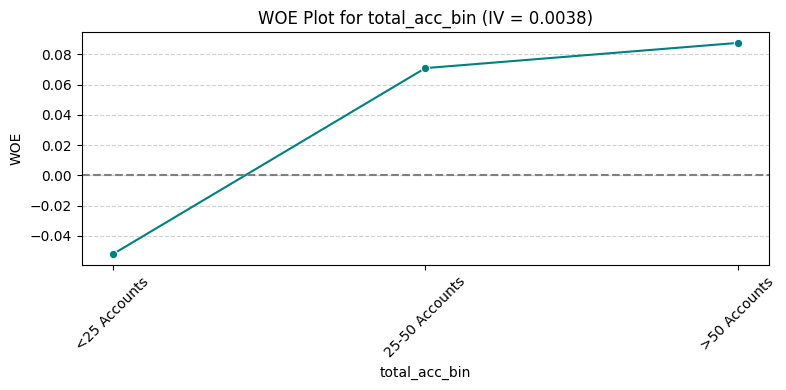

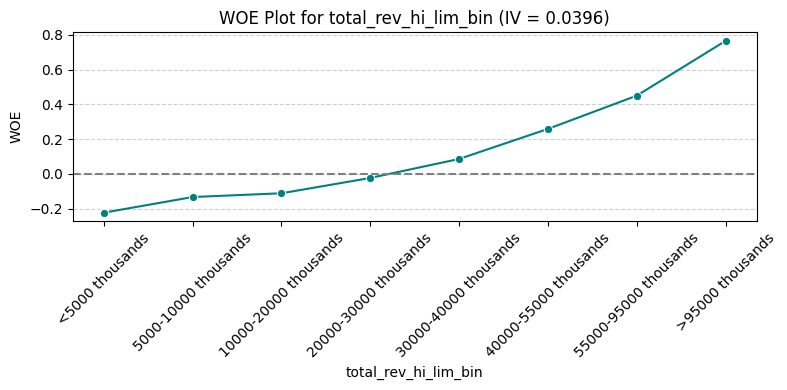

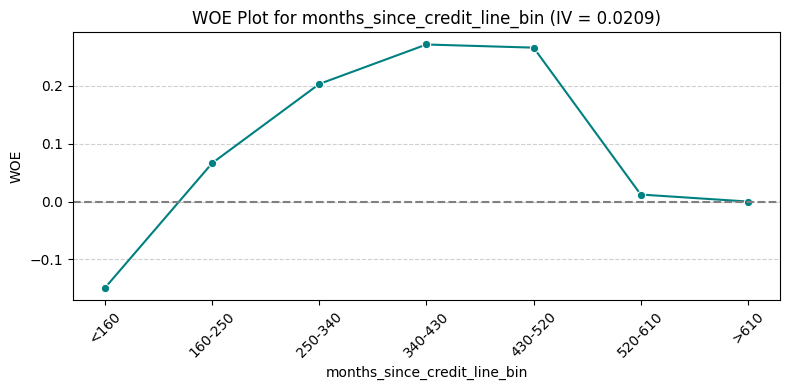

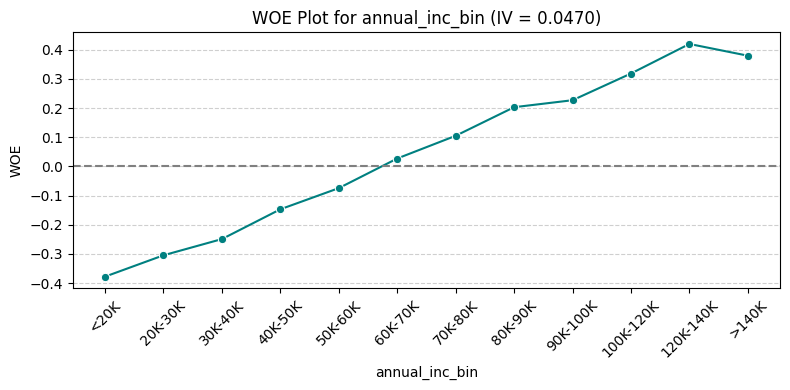

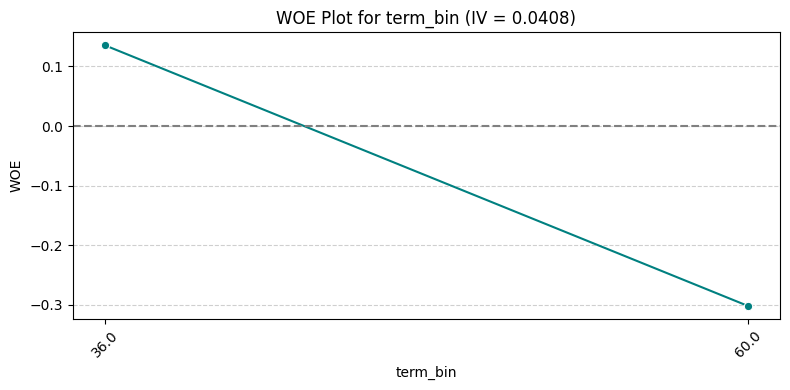

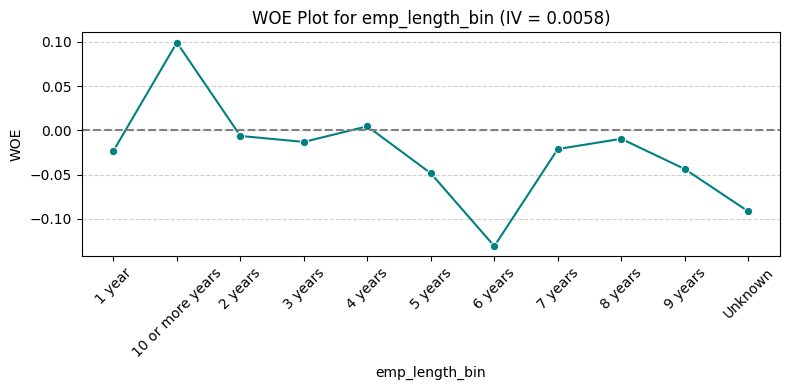

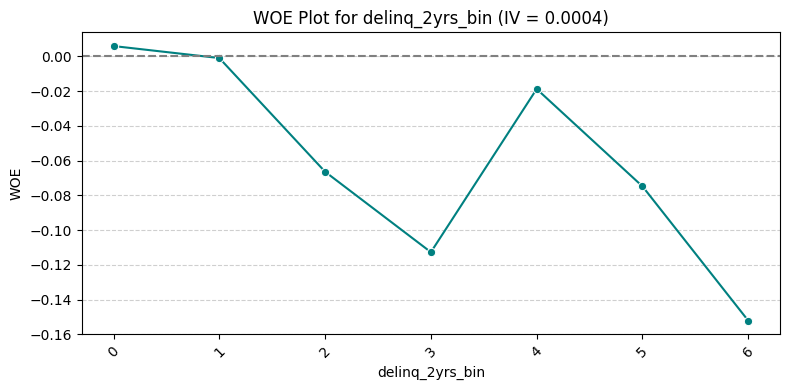

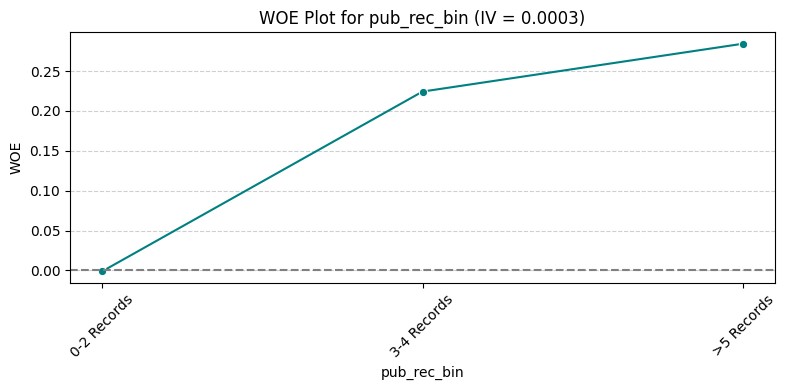

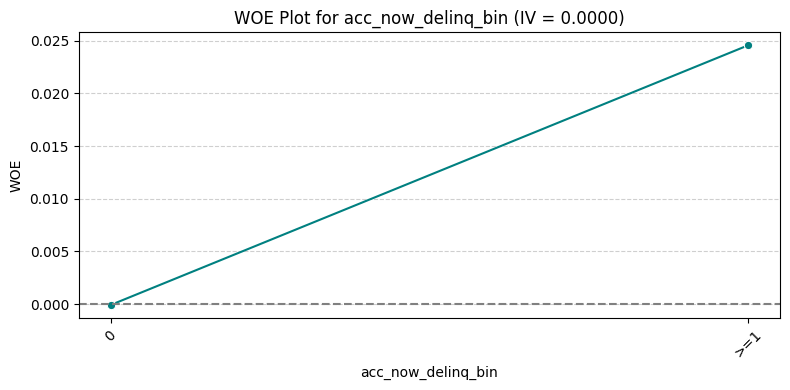

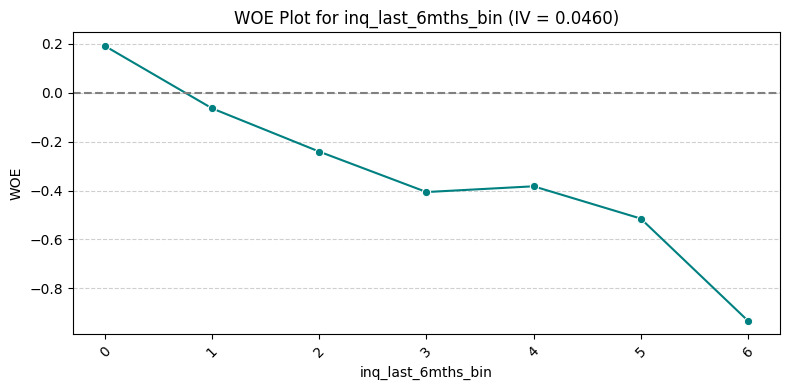

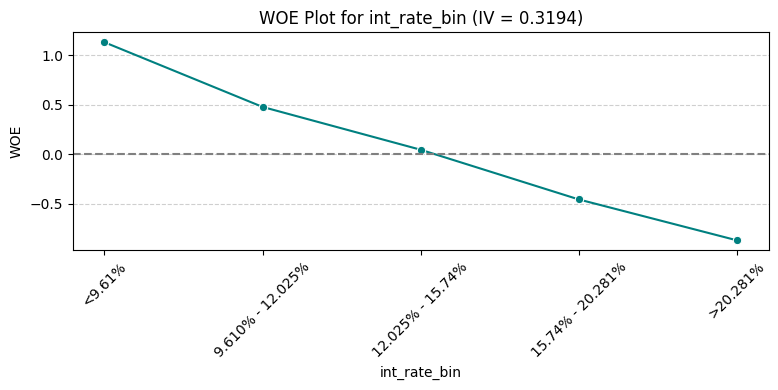

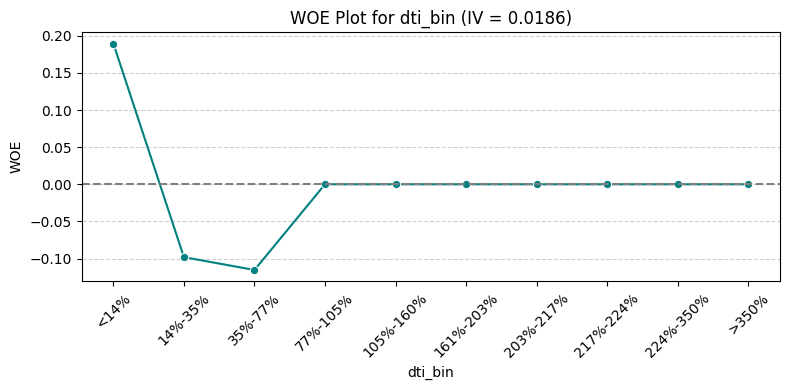

In [82]:
# Use only binned columns
binned_cols = [col for col in df.columns if col.endswith('_bin')]

for bin_col in binned_cols:
    try:
        if bin_col not in df.columns:
            print(f"Skipping {bin_col}: column not found.")
            continue
        if df[bin_col].isnull().sum() > 0:
            print(f"Skipping {bin_col}: contains null values.")
            continue
        if df[bin_col].nunique() <= 1:
            print(f"Skipping {bin_col}: only one unique value.")
            continue

        # Calculate WOE + IV
        woe_df, iv = calc_woe_iv(df, bin_col, 'loan_status')
        woe_df = woe_df[[bin_col, 'WoE', 'IV']]  # ✅ Select needed columns
        woe_df.columns = ['value', 'woe', 'iv']  # ✅ Now safe to rename

        woe_df = woe_df.sort_values(by='value')

        # Plot
        plt.figure(figsize=(8, 4))
        sns.lineplot(data=woe_df, x='value', y='woe', marker='o', color='teal')
        plt.title(f"WOE Plot for {bin_col} (IV = {iv:.4f})")
        plt.xlabel(bin_col)
        plt.ylabel("WOE")
        plt.axhline(0, color='gray', linestyle='--')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not plot WOE for {bin_col}: {e}")


In [83]:
# df.drop(columns=[col for col in df.columns if col.endswith('_bin')], inplace=True)


In [84]:
# Print WOE columns
woe_columns = [col for col in df.columns if col.endswith('_woe')]
print("Columns ending with '_woe':")
print(woe_columns)

# Print BIN columns
bin_columns = [col for col in df.columns if col.endswith('_bin')]
print("Columns ending with '_bin':")
print(bin_columns)


Columns ending with '_woe':
['annual_inc_bin_woe', 'int_rate_woe', 'open_acc_bin_woe', 'delinq_2yrs_bin_woe', 'term_bin_woe', 'pub_rec_bin_woe', 'total_acc_bin_woe', 'total_rev_hi_lim_bin_woe', 'months_since_credit_line_bin_woe', 'grade_woe', 'home_ownership_woe', 'addr_state_woe', 'verification_status_woe', 'purpose_woe', 'initial_list_status_woe', 'open_acc_woe', 'total_acc_woe', 'total_rev_hi_lim_woe', 'months_since_credit_line_woe', 'annual_inc_woe', 'term_woe', 'emp_length_woe', 'delinq_2yrs_woe', 'pub_rec_woe', 'acc_now_delinq_woe', 'inq_last_6mths_woe', 'dti_woe']
Columns ending with '_bin':
['open_acc_bin', 'total_acc_bin', 'total_rev_hi_lim_bin', 'months_since_credit_line_bin', 'annual_inc_bin', 'term_bin', 'emp_length_bin', 'delinq_2yrs_bin', 'pub_rec_bin', 'acc_now_delinq_bin', 'inq_last_6mths_bin', 'int_rate_bin', 'dti_bin']


In [85]:
# Remove any incorrectly named _bin_woe columns
df.drop(columns=[col for col in df.columns if '_bin_woe' in col], inplace=True)

df.drop(columns=['grade_woe'], inplace=True)

# Re-print cleaned WOE columns
woe_columns = [col for col in df.columns if col.endswith('_woe')]
print("Cleaned WOE columns:")
print(woe_columns)


Cleaned WOE columns:
['int_rate_woe', 'home_ownership_woe', 'addr_state_woe', 'verification_status_woe', 'purpose_woe', 'initial_list_status_woe', 'open_acc_woe', 'total_acc_woe', 'total_rev_hi_lim_woe', 'months_since_credit_line_woe', 'annual_inc_woe', 'term_woe', 'emp_length_woe', 'delinq_2yrs_woe', 'pub_rec_woe', 'acc_now_delinq_woe', 'inq_last_6mths_woe', 'dti_woe']


In [86]:
bin_cols = [col for col in df.columns if col.endswith('_bin')]
print(bin_cols)



woe_cols = [col for col in df.columns if col.endswith('_woe')]
print("🔎 WOE-transformed columns used for model/scorecard:", woe_cols)


['open_acc_bin', 'total_acc_bin', 'total_rev_hi_lim_bin', 'months_since_credit_line_bin', 'annual_inc_bin', 'term_bin', 'emp_length_bin', 'delinq_2yrs_bin', 'pub_rec_bin', 'acc_now_delinq_bin', 'inq_last_6mths_bin', 'int_rate_bin', 'dti_bin']
🔎 WOE-transformed columns used for model/scorecard: ['int_rate_woe', 'home_ownership_woe', 'addr_state_woe', 'verification_status_woe', 'purpose_woe', 'initial_list_status_woe', 'open_acc_woe', 'total_acc_woe', 'total_rev_hi_lim_woe', 'months_since_credit_line_woe', 'annual_inc_woe', 'term_woe', 'emp_length_woe', 'delinq_2yrs_woe', 'pub_rec_woe', 'acc_now_delinq_woe', 'inq_last_6mths_woe', 'dti_woe']


In [87]:
woe_map = {}
categorical_or_binned_features = ['home_ownership', 'addr_state', 'verification_status', 'purpose', 'initial_list_status', 'open_acc_bin', 'total_acc_bin', 'total_rev_hi_lim_bin', 'months_since_credit_line_bin', 'annual_inc', 'term', 'emp_length_bin', 'delinq_2yrs_bin', 'pub_rec_bin', 'acc_now_delinq_bin', 'inq_last_6mths_bin', 'int_rate_bin', 'dti_bin']
for col in categorical_or_binned_features:
    woe_df, _ = calc_woe_iv(df, col, 'loan_status')
    woe_map[col] = dict(zip(woe_df[col], woe_df['WoE']))


In [88]:
print(df.head())

   Unnamed: 0  loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  \
0           0       5000         5000           4975.0  36.0     10.65   
1           1       2500         2500           2500.0  60.0     15.27   
2           2       2400         2400           2400.0  36.0     15.96   
3           3      10000        10000          10000.0  36.0     13.49   
4           4       3000         3000           3000.0  60.0     12.69   

   installment grade  emp_length home_ownership             annual_inc  \
0       162.87     B          10           RENT  20000-30000 thousands   
1        59.83     C           0           RENT  20000-30000 thousands   
2        84.33     C          10           RENT       <20000 thousands   
3       339.31     C          10           RENT  40000-50000 thousands   
4        67.79     B           1           RENT  70000-80000 thousands   

  verification_status    issue_d  loan_status         purpose addr_state  \
0            Verified 2011-12-01  

# LOGISTIC REGRESSION, Z-SCORE

for col in df.columns:
    if col.endswith('_woe') and df[col].dtype != 'O':
        df[col + '_bin'] = (df[col] > 0).astype(int)


In [89]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# -------------------------------
# Step 1: Select WOE Features
# -------------------------------
woe_cols = [col for col in df.columns if col.endswith('_woe')]

X = df[woe_cols].copy()

# 🔥 FIX: Convert to float (VERY IMPORTANT)
X = X.astype(float)

y = df['loan_status']

# -------------------------------
# Step 2: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

# -------------------------------
# Step 3: Handle Missing Values
# -------------------------------
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# -------------------------------
# Step 4: SMOTE (Controlled)
# -------------------------------
smote = SMOTE(sampling_strategy=0.6, random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Convert back to DataFrame
X_res = pd.DataFrame(X_res, columns=X_train.columns)

# Ensure float type again
X_res = X_res.astype(float)
X_test = X_test.astype(float)

# -------------------------------
# Step 5: Feature Selection (Top 500)
# -------------------------------
temp_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

temp_model.fit(X_res, y_res)

importance = temp_model.feature_importances_
feat_imp = pd.Series(importance, index=X_res.columns).sort_values(ascending=False)

top_500 = feat_imp.head(500).index

X_res = X_res[top_500]
X_test = X_test[top_500]

# -------------------------------
# Step 6: Define Hybrid Models
# -------------------------------

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2,
    eval_metric='logloss',
    random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

# Hybrid Ensemble
hybrid_model = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('rf', rf)
    ],
    voting='soft'
)

# -------------------------------
# Step 7: Train Final Model
# -------------------------------
hybrid_model.fit(X_res, y_res)

# -------------------------------
# Step 8: Prediction
# -------------------------------
y_probs = hybrid_model.predict_proba(X_test)[:, 1]

# -------------------------------
# Step 9: Threshold Tuning
# -------------------------------
best_f1 = 0
best_thresh = 0.5

for t in np.arange(0.3, 0.7, 0.05):
    y_pred = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

y_pred_final = (y_probs >= best_thresh).astype(int)

# -------------------------------
# Step 10: Evaluation
# -------------------------------
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred_final))
print("🧾 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

print("🔥 Final F1 Score:", f1_score(y_test, y_pred_final))
print("🚀 AUC Score:", roc_auc_score(y_test, y_probs))

Best Threshold: 0.3

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00     13833
           1       0.88      1.00      0.94    102739

    accuracy                           0.88    116572
   macro avg       0.44      0.50      0.47    116572
weighted avg       0.78      0.88      0.83    116572

🧾 Confusion Matrix:
 [[     0  13833]
 [     0 102739]]
🔥 Final F1 Score: 0.9369251884310409
🚀 AUC Score: 0.6686665339087754


C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\amsdh\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [94]:
# -------------------------------
# Step 0: Import Libraries
# -------------------------------
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
df = pd.read_csv("loan_data_2007_2014 (1).csv", low_memory=False)

print("Dataset Shape:", df.shape)

# -------------------------------
# Step 2: Target Encoding
# -------------------------------
# Default = Charged Off (1), others = 0
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

print("Target Distribution:\n", df['loan_status'].value_counts())


# -------------------------------
# Step 3: Select Features
# -------------------------------
# Drop useless columns
leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv'
]

df = df.drop(columns=leakage_cols, errors='ignore')
drop_cols = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code',
    'issue_d', 'earliest_cr_line',
    'last_pymnt_d', 'last_credit_pull_d', 'next_pymnt_d'
]

df = df.drop(columns=drop_cols, errors='ignore')

# Select only numeric columns
X = df.select_dtypes(include=[np.number]).drop(columns=['loan_status'], errors='ignore')
y = df['loan_status']

print("Features used:", X.shape[1])

# -------------------------------
# Step 4: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 5: Handle Missing Values
# -------------------------------
median_vals = X_train.median()

X_train = X_train.fillna(median_vals)
X_test = X_test.fillna(median_vals)

# -------------------------------
# Step 6: Handle Imbalance
# -------------------------------
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("Class Distribution:", dict(zip([0,1], [neg,pos])))
print("Scale_pos_weight:", scale_pos_weight)

# -------------------------------
# Step 7: Feature Selection
# -------------------------------
temp_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

temp_model.fit(X_train, y_train)

feat_imp = pd.Series(temp_model.feature_importances_, index=X_train.columns)
top_features = feat_imp.sort_values(ascending=False).head(50).index  # reduced for stability

X_train = X_train[top_features]
X_test = X_test[top_features]

# -------------------------------
# Step 8: Define Models
# -------------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

hybrid_model = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    voting='soft'
)

# -------------------------------
# Step 9: Train Model
# -------------------------------
hybrid_model.fit(X_train, y_train)

# -------------------------------
# Step 10: Prediction
# -------------------------------
y_probs = hybrid_model.predict_proba(X_test)[:, 1]

# -------------------------------
# Step 11: Threshold Tuning
# -------------------------------
best_f1 = 0
best_thresh = 0.5

for t in np.arange(0.2, 0.8, 0.02):
    y_pred = (y_probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("✅ Best Threshold:", best_thresh)

y_pred_final = (y_probs >= best_thresh).astype(int)

# -------------------------------
# Step 12: Evaluation
# -------------------------------
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred_final))
print("🧾 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

print("🔥 Final F1 Score:", f1_score(y_test, y_pred_final))
print("🚀 AUC Score:", roc_auc_score(y_test, y_probs))

Dataset Shape: (466285, 75)
Target Distribution:
 loan_status
0    184739
1     42475
Name: count, dtype: int64
Features used: 41
Class Distribution: {0: np.int64(147791), 1: np.int64(33980)}
Scale_pos_weight: 4.3493525603296055
✅ Best Threshold: 0.5199999999999998

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.71      0.79     36948
           1       0.32      0.60      0.42      8495

    accuracy                           0.69     45443
   macro avg       0.60      0.65      0.60     45443
weighted avg       0.78      0.69      0.72     45443

🧾 Confusion Matrix:
 [[26297 10651]
 [ 3424  5071]]
🔥 Final F1 Score: 0.41879671305281413
🚀 AUC Score: 0.7142135427528933
